In [39]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [40]:
from sklearn.datasets import load_iris

iris = load_iris()
# The data is stored in a numpy array, you can convert it to a pandas DataFrame if needed.
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [41]:
df = df[df['target']!=0][['sepal width (cm)','petal length (cm)','target']]

In [42]:
df.head()

,sepal width (cm),petal length (cm),target
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

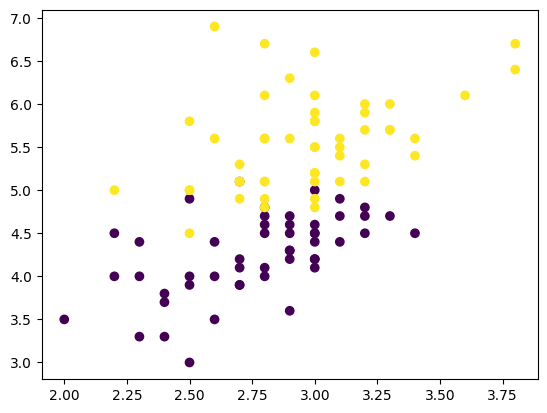

In [44]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c =df['target'])

In [45]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [46]:
df_train

,sepal width (cm),petal length (cm),target
129,3.0,5.8,2
76,2.8,4.8,1
114,2.8,5.1,2
80,2.4,3.8,1
105,3.0,6.6,2
143,3.2,5.9,2
106,2.5,4.5,2
82,2.7,3.9,1
124,3.3,5.7,2
146,2.5,5.0,2


In [47]:
df_val

,sepal width (cm),petal length (cm),target
81,2.4,3.7,1
71,2.8,4.0,1
141,3.1,5.1,2
59,2.7,3.9,1
84,3.0,4.5,1


In [48]:
df_test

,sepal width (cm),petal length (cm),target
132,2.8,5.6,2
58,2.9,4.6,1
61,3.0,4.2,1
113,2.5,5.0,2
57,2.4,3.3,1


In [49]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# **Case 1 - Bagging**

In [50]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),target
105,3.0,6.6,2
80,2.4,3.8,1
82,2.7,3.9,1
80,2.4,3.8,1
146,2.5,5.0,2
114,2.8,5.1,2
114,2.8,5.1,2
114,2.8,5.1,2


In [51]:
!pip install mlxtend

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [54]:
dt_bag1 = DecisionTreeClassifier()

In [60]:
def evaluate(clf, X, y):
  """Evaluates a model on the given data."""
  clf.fit(X,y)
  plot_tree(clf,filled=True)
  plt.show()
  plot_decision_regions(X.values, y.values, clf=clf, legend=2)
  y_pred = clf.predict(X)
  accuracy = accuracy_score(y, y_pred)
  print(f"Accuracy: {accuracy}")

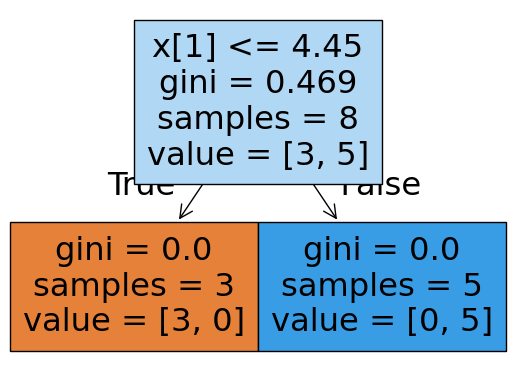

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy: 1.0


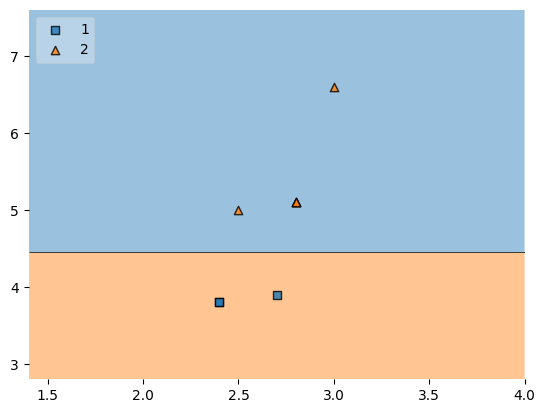

In [61]:
evaluate(dt_bag1,X,y)

In [64]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),target
146,2.5,5.0,2
105,3.0,6.6,2
129,3.0,5.8,2
80,2.4,3.8,1
114,2.8,5.1,2
129,3.0,5.8,2
80,2.4,3.8,1
106,2.5,4.5,2


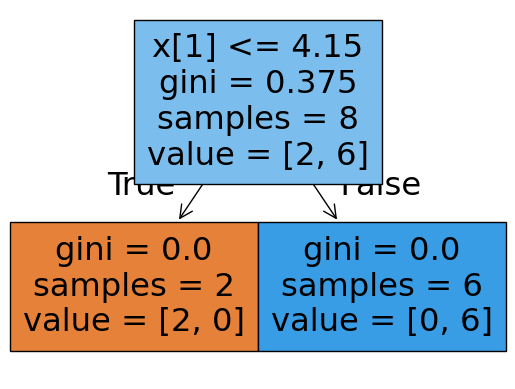

Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


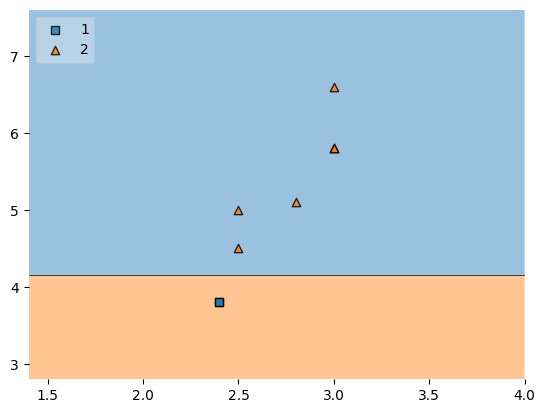

In [65]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [66]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),target
146,2.5,5.0,2
143,3.2,5.9,2
143,3.2,5.9,2
124,3.3,5.7,2
129,3.0,5.8,2
129,3.0,5.8,2
76,2.8,4.8,1
106,2.5,4.5,2


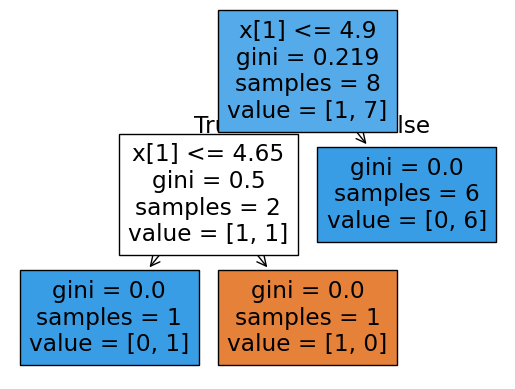

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Accuracy: 1.0


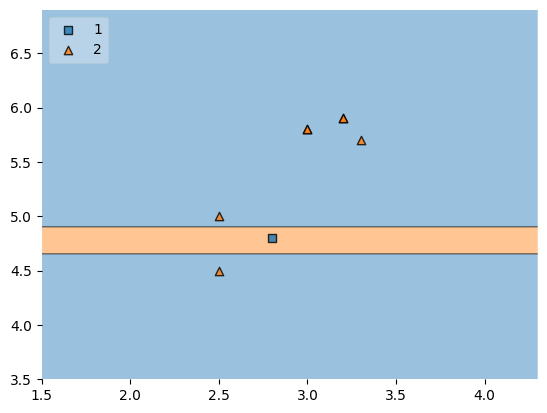

In [67]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# **Predict**

In [71]:
df_test

,sepal width (cm),petal length (cm),target
132,2.8,5.6,2
58,2.9,4.6,1
61,3.0,4.2,1
113,2.5,5.0,2
57,2.4,3.3,1


In [73]:
print(dt_bag1.predict(np.array([2.9	,4.6]).reshape(1,2)))
print(dt_bag2.predict(np.array([2.9,	4.6]).reshape(1,2)))
print(dt_bag3.predict(np.array([2.9	,4.6]).reshape(1,2)))

[2]
[2]
[2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **Pasting**

In [74]:
df_train

,sepal width (cm),petal length (cm),target
129,3.0,5.8,2
76,2.8,4.8,1
114,2.8,5.1,2
80,2.4,3.8,1
105,3.0,6.6,2
143,3.2,5.9,2
106,2.5,4.5,2
82,2.7,3.9,1
124,3.3,5.7,2
146,2.5,5.0,2


In [75]:
df_train.sample(8,replace=False)

,sepal width (cm),petal length (cm),target
129,3.0,5.8,2
105,3.0,6.6,2
146,2.5,5.0,2
106,2.5,4.5,2
143,3.2,5.9,2
80,2.4,3.8,1
82,2.7,3.9,1
114,2.8,5.1,2


# **Random Subspace**

In [76]:
df = df.sample(10)

In [77]:
df

,sepal width (cm),petal length (cm),target
149,3.0,5.1,2
126,2.8,4.8,2
64,2.9,3.6,1
105,3.0,6.6,2
115,3.2,5.3,2
85,3.4,4.5,1
88,3.0,4.1,1
129,3.0,5.8,2
78,2.9,4.5,1
110,3.2,5.1,2


In [79]:
df.sample(2,axis=1)

,petal length (cm),sepal width (cm)
149,5.1,3.0
126,4.8,2.8
64,3.6,2.9
105,6.6,3.0
115,5.3,3.2
85,4.5,3.4
88,4.1,3.0
129,5.8,3.0
78,4.5,2.9
110,5.1,3.2


# **Random patches**

In [83]:
df.sample(8,replace=True).sample(2,replace= True,axis=1)

,petal length (cm),target
78,4.5,1
110,5.1,2
110,5.1,2
115,5.3,2
64,3.6,1
78,4.5,1
85,4.5,1
88,4.1,1
